In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("Imports Done!")

Imports Done!


# Step 1 - Profiling
1. import the "Titanic" dataset using seaborn as a data frame
2. Store the df as a csv
3. show info(), describe() and shape on this data set
4. compute percentage of missing values in columns that have any

In [2]:
# import titanic data set from seaborn
titanic_df = sns.load_dataset("titanic")
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
# save it as a .csv file
titanic_df.to_csv(path_or_buf = 'titanic_raw.csv', mode = 'w', index = False)

In [4]:
# show shape, info and describe
print(f"The shape of the titanic data frame - {titanic_df.shape}")
print("-" * 20)
print("Data Frame Info:\n")
print(titanic_df.info())
print("-" * 20)
print("data frame describe():\n")
print(titanic_df.describe())
print("-" * 20)

The shape of the titanic data frame - (891, 15)
--------------------
Data Frame Info:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
--

In [5]:
# show % of null values in the data set
df_len = len(titanic_df)
print(f"{"Column":<15}{"% null values"}")
print("-" * 30)
for column in titanic_df.columns:
    percent_null_values = (titanic_df[column].isna().sum() / df_len) * 100
    print(f"{column:<15}{percent_null_values:.2f}")

Column         % null values
------------------------------
survived       0.00
pclass         0.00
sex            0.00
age            19.87
sibsp          0.00
parch          0.00
fare           0.00
embarked       0.22
class          0.00
who            0.00
adult_male     0.00
deck           77.22
embark_town    0.22
alive          0.00
alone          0.00


# Step 2 - Cleaning
1. drop columns containing duplicated information -> Feature Elimination
    - class - as its just a text description of pclass column
    - who - as it is just a description of sex column
    - adult_male - as it is just a derived column from sex and age columns
    - embark_town - as its a description to the embarked column
    - alone - its just a derived column from sibsp and parch
    - alive - same as survived
2. Handle missing values
    - age -> as there are ~20% missing values impute these missing values using strategy as median
    - embarked -> as only 0.22 % of rows have missing values remove the rows entirely
    - deck -> as > 70 % values are missing remove the feature entirely

In [6]:
# drop the unessary columns
columns_to_be_dropped = [
    "class",
    "who",
    "adult_male",
    "embark_town",
    "alone",
    "alive"
]
titanic_df.drop(columns = columns_to_be_dropped, inplace = True)
print(f"Columns {columns_to_be_dropped} are dropped from the data frame")
print("info() after dropping unnessasary columns")
print("-" * 20)
print(titanic_df.info())
print("-" * 20)

Columns ['class', 'who', 'adult_male', 'embark_town', 'alone', 'alive'] are dropped from the data frame
info() after dropping unnessasary columns
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    str     
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    str     
 8   deck      203 non-null    category
dtypes: category(1), float64(2), int64(4), str(2)
memory usage: 57.0 KB
None
--------------------


In [7]:
# impute age
titanic_df["age"] = titanic_df["age"].fillna(titanic_df["age"].median())

# handle the embarked column
titanic_df.dropna(subset = ["embarked"], inplace=True)

# remove deck column
titanic_df.drop(columns = ["deck"], inplace = True)

print(f"Columns age, embarked and deck are handled for missing values")
print("info() after handling missing values")
print("-" * 20)
print(titanic_df.info())
print("-" * 20)

Columns age, embarked and deck are handled for missing values
info() after handling missing values
--------------------
<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    str    
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 62.5 KB
None
--------------------


In [8]:
# save the cleaned file as a .csv
titanic_df.to_csv(path_or_buf = 'titanic_cleaned.csv', mode = 'w', index = False)

# Step 3 - Univariate Analysis
1. plot hist and box plots for age and fare columns
2. report number of outliers in age and fare columns
3. compute mean, median and mode for fare column

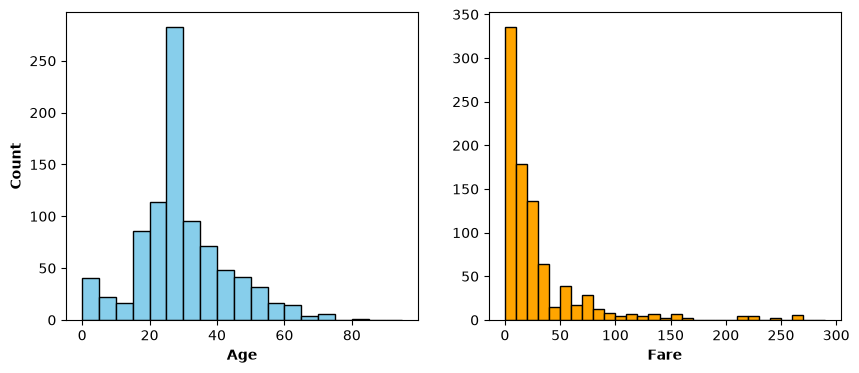

In [9]:
# plot histograms on age and fare columns

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
bins_for_age = np.arange(0, 100, 5)
bins_for_fare = np.arange(0, 300, 10)

ax1.hist(titanic_df["age"], bins=bins_for_age, color="skyblue", edgecolor="black")
ax1.set_xlabel("Age", fontweight="bold")
ax1.set_ylabel("Count", fontweight="bold")

ax2.hist(titanic_df["fare"], bins=bins_for_fare, color="orange", edgecolor="black")
ax2.set_xlabel("Fare", fontweight="bold")
# ax2.set_ylabel("Count")

plt.show()


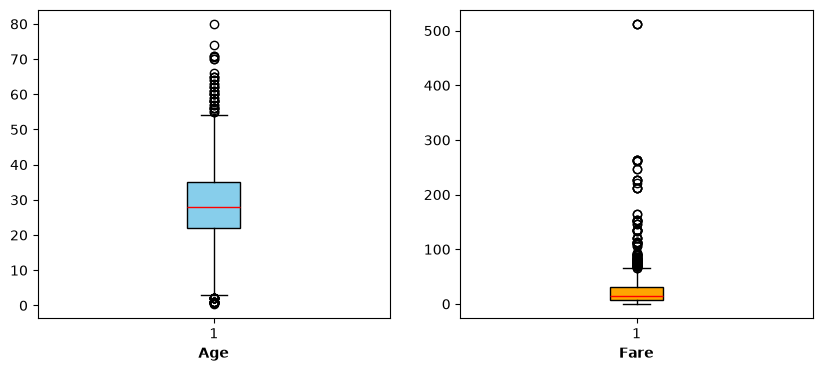

In [10]:
# plot bos plots for age and fare columns

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

age_plot = ax1.boxplot(titanic_df["age"], patch_artist=True, 
           boxprops=dict(facecolor='skyblue', color='black'),
           medianprops=dict(color='red'))
ax1.set_xlabel("Age", fontweight="bold")

fare_plot = ax2.boxplot(titanic_df["fare"], patch_artist=True, 
           boxprops=dict(facecolor='orange', color='black'),
           medianprops=dict(color='red'))
ax2.set_xlabel("Fare", fontweight="bold")

plt.show()

In [11]:
# Outliers in fare and age columns
age_outliers = [float(i) for i in age_plot["fliers"][0].get_ydata()]
fare_outliers = [float(i) for i in fare_plot["fliers"][0].get_ydata()]
age_outliers.sort()
fare_outliers.sort()
print(f"The outliers in age data are - {age_outliers}")
print(f"The outliers in fare data are - {fare_outliers}")
print("Analysis: All the ages <= 2 years and >= 55 years are ouliers")
print(f"Analysis: All the fares >= 66.6 bucks are outliers")

The outliers in age data are - [0.42, 0.67, 0.75, 0.75, 0.83, 0.83, 0.92, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 55.0, 55.0, 55.5, 56.0, 56.0, 56.0, 56.0, 57.0, 57.0, 58.0, 58.0, 58.0, 58.0, 58.0, 59.0, 59.0, 60.0, 60.0, 60.0, 60.0, 61.0, 61.0, 61.0, 62.0, 62.0, 62.0, 63.0, 63.0, 64.0, 64.0, 65.0, 65.0, 65.0, 66.0, 70.0, 70.0, 70.5, 71.0, 71.0, 74.0, 80.0]
The outliers in fare data are - [66.6, 66.6, 69.3, 69.3, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 71.0, 71.0, 71.2833, 73.5, 73.5, 73.5, 73.5, 73.5, 75.25, 76.2917, 76.7292, 76.7292, 76.7292, 77.2875, 77.2875, 77.9583, 77.9583, 77.9583, 78.2667, 78.2667, 78.85, 78.85, 79.2, 79.2, 79.2, 79.2, 79.65, 79.65, 79.65, 81.8583, 82.1708, 82.1708, 83.1583, 83.1583, 83.1583, 83.475, 83.475, 86.5, 86.5, 86.5, 89.1042, 89.1042, 90.0, 90.0, 90.0, 90.0, 91.0792, 91.0792, 93.5, 93.5, 106.425, 106.425, 108.9, 108.9, 110.8833, 110.8833, 110.8833, 110.8833, 113.275, 113.275, 113.275, 120.0, 120.0, 

In [12]:
# calculate mean, median and mode for age and fare columns
age_mean = float(titanic_df["age"].mean()).__round__(2)
age_median = float(titanic_df["age"].median()).__round__(2)
age_mode = float(titanic_df["age"].mode()[0]).__round__(2)

fare_mean = float(titanic_df["fare"].mean()).__round__(2)
fare_median = float(titanic_df["fare"].median()).__round__(2)
fare_mode = float(titanic_df["fare"].mode()[0]).__round__(2)

print(f"{"column":<10}{"Mean":<10}{"Median":<10}{"Mode":<10}")
print("-" * 40)
print(f"{"Age":<10}{age_mean:<10}{age_median:<10}{age_mode:<10}")
print(f"{"Fare":<10}{fare_mean:<10}{fare_median:<10}{fare_mode:<10}")

column    Mean      Median    Mode      
----------------------------------------
Age       29.32     28.0      28.0      
Fare      32.1      14.45     8.05      


__Skweness of age and fare columns__
- for `age` column as Mean > Median = Mode -> long tail extends towards right but as difference between mean and median is not so large, the distribution can be said as __moderately right-skewed__
- for `fare` column as Mean > Median > Mode -> long tail extends towards right but as difference between mean and median and mode is large, the distribution can be said as __highly right-skewed__

# Step 4 - Bivariate Analysis
1. compute survival rate % by sex
2. compute survival rate % by pclass
3. compute survival rate % by sex and pclass together
4. compute a correlation matrix using the these six columns: survived, pclass, age, sibsp, parch, and fare
5. draw a heatmap of these correleations.

In [13]:
# survival rate % by sex
no_of_survived = titanic_df[titanic_df["survived"] == 1].shape[0]
no_of_male_survived = titanic_df[(titanic_df["sex"] == "male") & (titanic_df["survived"] == 1)].shape[0]
no_of_female_survived = titanic_df[(titanic_df["sex"] == "female") & (titanic_df["survived"] == 1)].shape[0]
print("Survival rate by gender")
print("-" * 25)
print(f"{"sex":<10}{"survival rate":<15}")
print("-" * 25)
print(f"{"male":<10}{((no_of_male_survived / no_of_survived) * 100) :.2f}")
print(f"{"female":<10}{((no_of_female_survived / no_of_survived) * 100) :.2f}")

Survival rate by gender
-------------------------
sex       survival rate  
-------------------------
male      32.06
female    67.94


In [14]:
# survival rate % by pclass
print("Survival rate by pclass")
print("-" * 25)
print(f"{"pclass":<10}{"survival rate":<15}")
print("-" * 25)
for pclass, rate in (titanic_df.groupby("pclass")["survived"].agg("mean") * 100).items():
    print(f"{pclass:<10}{rate:.2f}")

Survival rate by pclass
-------------------------
pclass    survival rate  
-------------------------
1         62.62
2         47.28
3         24.24


In [15]:
# survival rate % by pclass and sex
print("Survival rate by pclass and sex")
print("-" * 35)
print(f"{"pclass":<10}{"sex":<10}{"survival rate":<15}")
print("-" * 35)
agg = titanic_df.groupby(["pclass", "sex"])["survived"].agg("mean") * 100
for a, rate in agg.items():
    print(f"{a[0]:<10}{a[1]:<10}{rate:.2f}")

Survival rate by pclass and sex
-----------------------------------
pclass    sex       survival rate  
-----------------------------------
1         female    96.74
1         male      36.89
2         female    92.11
2         male      15.74
3         female    50.00
3         male      13.54


In [16]:
# compute correlation matrix
corr_matrix = titanic_df.corr(numeric_only=True)
correlations = {}
for feature, corr_dict in corr_matrix.to_dict().items():
    for i in corr_dict:
        if feature == i:
            continue
        key = [feature, i]
        key.sort()
        correlations[":".join(key)] = round(corr_dict[i], 4)
correlations = list(correlations.items())
correlations.sort(reverse = True, key = lambda x: abs(x[1]))
print("Correlations in descending order")
print("-" * 50)
print(f"{"Feature 1":<15}{"Ferature 2":<15}{"Correlation":<15}")
print("-" * 50)
for rank, i in enumerate(correlations):
    feature1 = i[0].split(':')[0]
    feature2 = i[0].split(':')[1]
    print(f"{feature1:<15}{feature2:<15}{i[1]:>7}{" -> Top 1" if rank == 0 else ''}{" -> Top 2" if rank == 1 else ''}")


Correlations in descending order
--------------------------------------------------
Feature 1      Ferature 2     Correlation    
--------------------------------------------------
fare           pclass         -0.5482 -> Top 1
parch          sibsp           0.4145 -> Top 2
age            pclass         -0.3365
pclass         survived       -0.3355
fare           survived        0.2553
age            sibsp          -0.2325
fare           parch           0.2175
age            parch          -0.1715
fare           sibsp           0.1609
age            fare            0.0937
parch          survived        0.0832
pclass         sibsp           0.0817
age            survived       -0.0698
sibsp          survived        -0.034
parch          pclass          0.0168


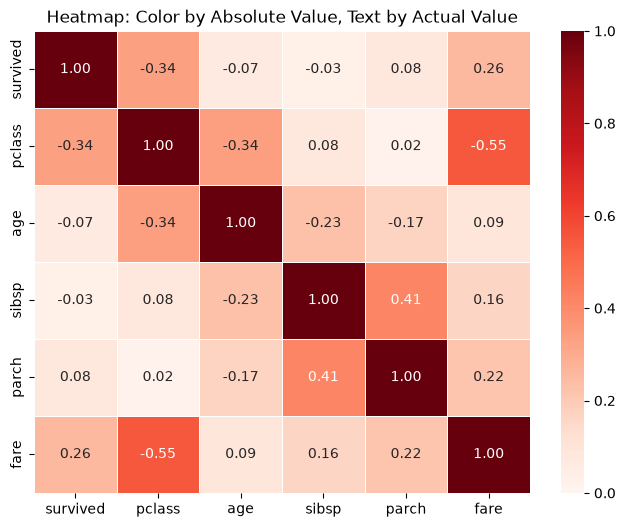

In [17]:
# draw heat map
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    data=corr_matrix.abs(), 
    annot=corr_matrix,
    fmt=".2f",
    vmin=-0, vmax=1,
    linewidths=0.5,
    cmap="Reds",
    ax = ax
)
ax.set_title('Heatmap: Color by Absolute Value, Text by Actual Value')
plt.show()

# Step 5 - Data Story

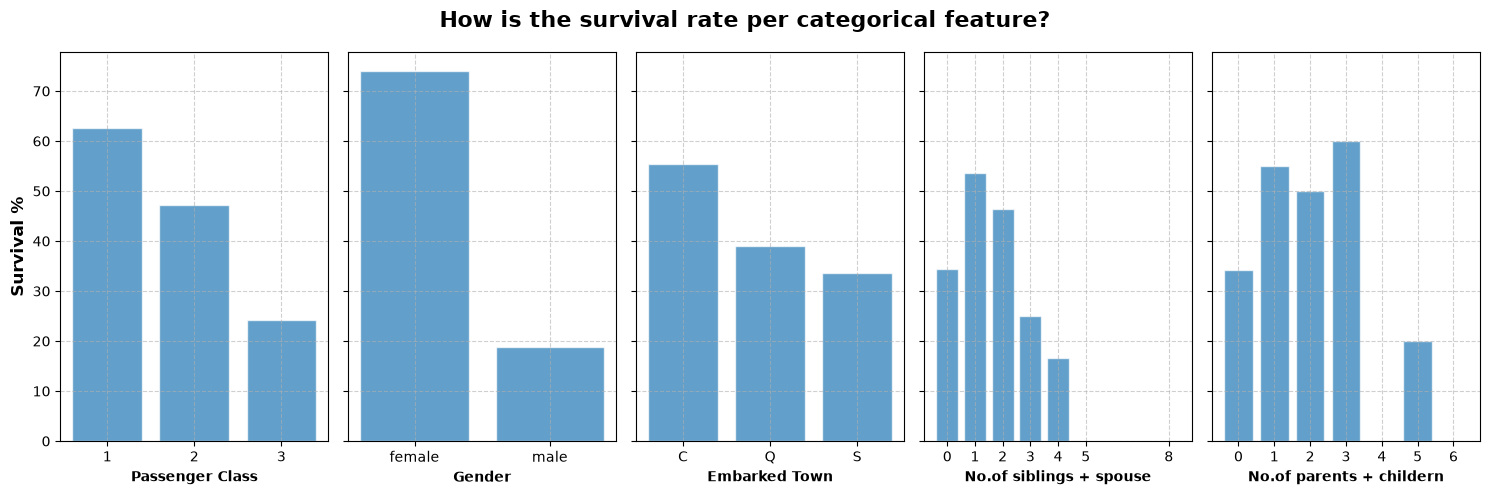

In [18]:
# Draw a pair plot with Y axis as survived column
cat_cols = ["pclass", "sex", "embarked", "sibsp", "parch"]
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5), sharey=True)
fig.suptitle("How is the survival rate per categorical feature?", fontsize=16, fontweight='bold')
desc = {
    "pclass": "Passenger Class",
    "sex": "Gender",
    "embarked": "Embarked Town",
    "sibsp": "No.of siblings + spouse",
    "parch": "No.of parents + childern"
}
for i, col in enumerate(cat_cols):
    agg = titanic_df.groupby(col)["survived"].mean() * 100
    ax = axes[i]
    ax.bar(agg.index, agg.values, alpha=0.7, edgecolor='white')
    ax.set_xlabel(desc[col], fontweight='bold')
    if col in ["sibsp", "parch"]:
        ax.set_xticks(agg.index)
    ax.grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylabel("Survival %", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

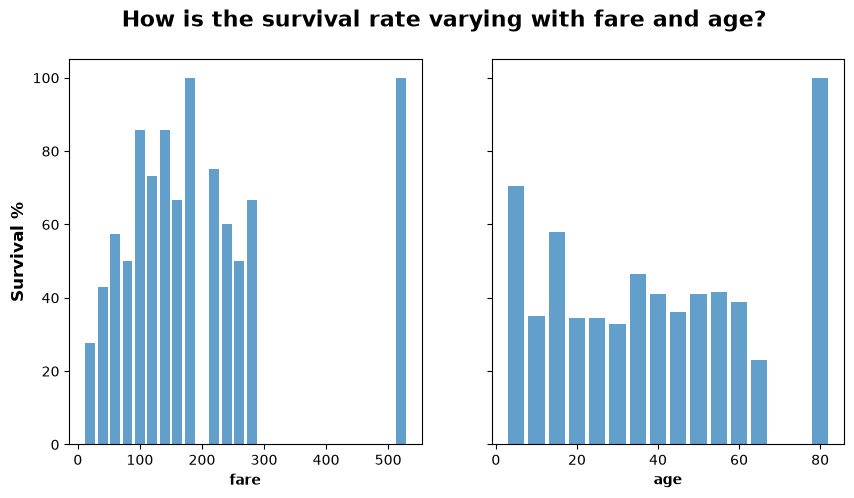

In [19]:
fare_bins = list(range(0, 540, 20))
age_bins = list(range(0, 100, 5))
titanic_df['fare_group'] = pd.cut(titanic_df['fare'], bins=fare_bins, labels=fare_bins[1:], include_lowest=True)
titanic_df['age_group'] = pd.cut(titanic_df['age'], bins=age_bins, labels=age_bins[1:], include_lowest=True)
fare_agg = titanic_df.groupby("fare_group")["survived"].mean() * 100
age_agg = titanic_df.groupby("age_group")["survived"].mean() * 100

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 5))
fig.suptitle("How is the survival rate varying with fare and age?", fontsize=16, fontweight='bold')
ax1.bar(fare_agg.index, fare_agg.values, width=16, alpha=0.7)
ax1.set_xlabel("fare", fontweight='bold')
ax1.set_ylabel("Survival %", fontweight='bold', fontsize=12)

ax2.bar(age_agg.index, age_agg.values, width=4, alpha=0.7)
ax2.set_xlabel("age", fontweight='bold')

plt.show()

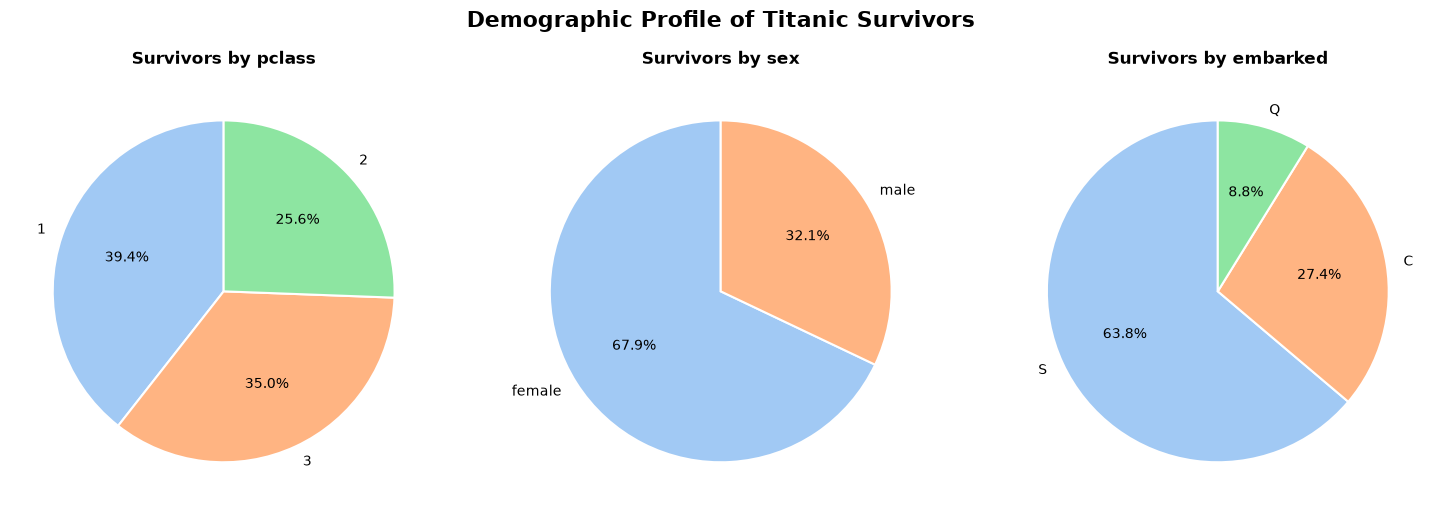

In [20]:
features_for_pie = ["pclass", "sex", "embarked"]
fig, axes = plt.subplots(nrows=1, ncols=len(features_for_pie), figsize=(15, 5))
for i, feature in enumerate(features_for_pie):
    ax = axes[i]
    counts = titanic_df[titanic_df["survived"] == 1][feature].value_counts()
    ax.pie(counts.values, 
           labels=counts.index, 
           autopct='%1.1f%%',
           startangle=90,
           colors=sns.color_palette("pastel"),
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(f'Survivors by {feature}', fontweight='bold', pad=10)
fig.suptitle("Demographic Profile of Titanic Survivors", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

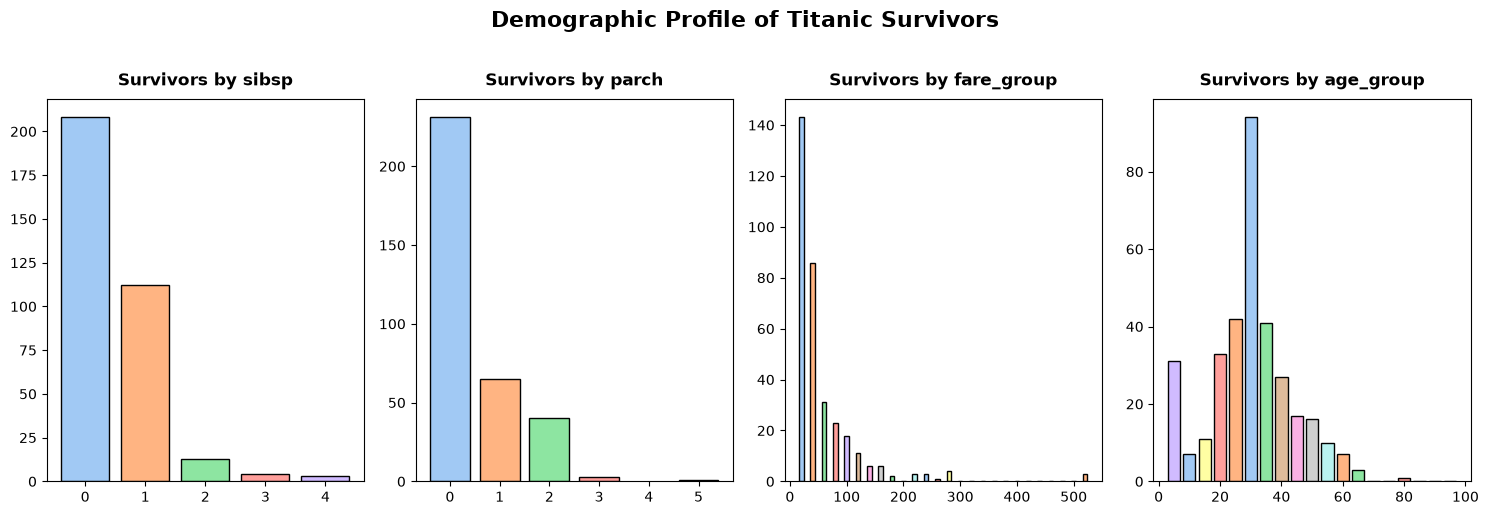

In [21]:
features_for_hist = ["sibsp", "parch", "fare_group", "age_group"]
fig, axes = plt.subplots(nrows=1, ncols=len(features_for_hist), figsize=(15, 5))
for i, feature in enumerate(features_for_hist):
    ax = axes[i]
    counts = titanic_df[titanic_df["survived"] == 1][feature].value_counts()
    my_colors = sns.color_palette("pastel", len(counts))
    if feature == "fare_group":
        bars = ax.bar(counts.index, counts.values, color=my_colors, edgecolor='black', width=8)
    elif feature == "age_group":
        bars = ax.bar(counts.index, counts.values, color=my_colors, edgecolor='black', width=4)
    else:
        bars = ax.bar(counts.index, counts.values, color=my_colors, edgecolor='black')
    ax.set_title(f'Survivors by {feature}', fontweight='bold', pad=10)
fig.suptitle("Demographic Profile of Titanic Survivors", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**The Dual Narrative of Titanic Survivors: Survival Rates vs. Final Demographics**

An analysis of the Titanic dataset reveals two distinct stories: the statistical probability of surviving a specific demographic group (survival rates) versus the actual makeup of the people who lived (absolute counts among survivors). While the "women and children first" protocol and wealth advantages clearly drove survival odds, the sheer size of the lower classes heavily influenced the final demographics of the survivors.

**The Probability of Survival (Survival Rates)**
Examining the survival rates highlights the distinct advantages held by certain passenger groups.
*   Gender was the most decisive factor; females had a survival rate exceeding 70%, while the male survival rate remained below 20%.
*   Age heavily influenced odds, with the youngest passengers (ages 0 to 10) experiencing the highest survival rate at approximately 70%.
*   Socioeconomic status provided a massive advantage, as Class 1 passengers survived at a rate of over 60%, compared to roughly 47% for Class 2 and less than 25% for Class 3. 
*   This wealth disparity is mirrored in ticket prices, where passengers in the highest fare brackets saw survival rates jumping between 80% and 100%.
*   Family size also dictated outcomes; those traveling with a small family (exactly one sibling/spouse or up to three parents/children) saw their survival odds peak between 50% and 60%.
*   Passengers embarking from town 'C' had the most favorable odds based on location, with a survival rate above 50%.

**The Composition of the Survivors (Absolute Counts)**
When looking at the absolute counts and proportions of those who survived, the narrative shifts, proving that high odds did not always equate to the highest total numbers.
*   Because of the stark difference in survival rates, females constituted the strong majority (67.9%) of all survivors, leaving males at 32.1%.
*   Despite children having the highest statistical likelihood of living, the largest absolute number of survivors fell into the 20-to-30 age bracket.
*   Although Class 1 had the best survival odds, the immense volume of lower-class passengers meant Class 3 still made up 35.0% of the total survivors, closely trailing the 39.4% from Class 1.
*   This volume effect is also visible in ticket prices, as the highest absolute count of survivors actually came from the lowest fare group.
*   While traveling with a small family provided the best statistical odds, the vast majority of the people who survived were traveling entirely alone, recording zero siblings, spouses, parents, or children.
*   Finally, despite town 'C' offering the best odds, the bulk of the surviving population (63.8%) embarked from town 'S'.

# Step 6 - Exploratory check
1. calculate mean for fare and age columns
2. calculate standard deviation for fare and age columns
3. standardize the age and mean column with the formula `z = (x − mean) / std`
4. compare the mean and standard deviation of the age and fare
columns before and after standardization.

In [22]:
fare_mean = titanic_df["fare"].mean()
fare_std = titanic_df["fare"].std()
age_mean = titanic_df["age"].mean()
age_std = titanic_df["age"].std()

print("Before Standardizatrion")
print("-" * 25)
print(f"{"fare/age":<10}{"mean":<10}{"std":<10}")
print("-" * 25)
print(f"{"fare":<10}{round(fare_mean, 2):<10}{round(fare_std, 2):<10}")
print(f"{"age":<10}{round(age_mean, 2):<10}{round(age_std, 2):<10}")

Before Standardizatrion
-------------------------
fare/age  mean      std       
-------------------------
fare      32.1      49.7      
age       29.32     12.98     


In [23]:
titanic_df["standardized_age"] = (titanic_df["age"] - age_mean) / age_std
titanic_df["standardized_fare"] = (titanic_df["fare"] - fare_mean) / fare_std
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_group,age_group,standardized_age,standardized_fare
0,0,3,male,22.0,1,0,7.2500,S,20,25,-0.563357,-0.499958
1,1,1,female,38.0,1,0,71.2833,C,80,40,0.668840,0.788503
2,1,3,female,26.0,0,0,7.9250,S,20,30,-0.255308,-0.486376
3,1,1,female,35.0,1,0,53.1000,S,60,35,0.437803,0.422623
4,0,3,male,35.0,0,0,8.0500,S,20,35,0.437803,-0.483861
5,0,3,male,28.0,0,0,8.4583,Q,20,30,-0.101283,-0.475645
6,0,1,male,54.0,0,0,51.8625,S,60,55,1.901038,0.397723
7,0,3,male,2.0,3,1,21.0750,S,40,5,-2.103604,-0.221775
8,1,3,female,27.0,0,2,11.1333,S,20,30,-0.178295,-0.421820
9,1,2,female,14.0,1,0,30.0708,C,40,15,-1.179456,-0.040764


In [24]:
print("After Standardizatrion")
print("-" * 35)
print(f"{"column":<20}{"mean":<10}{"std":<10}")
print("-" * 35)
print(f"{"standardized fare":<20}{round(titanic_df["standardized_fare"].mean(), 2):<10}{round(titanic_df["standardized_fare"].std(), 2):<10}")
print(f"{"standardized age":<20}{round(titanic_df["standardized_age"].mean(), 2):<10}{round(titanic_df["standardized_age"].std(), 2):<10}")

After Standardizatrion
-----------------------------------
column              mean      std       
-----------------------------------
standardized fare   0.0       1.0       
standardized age    0.0       1.0       
